# Comprensión del negocio
 
- **Contexto**
 
La empresa opera una plataforma de comercio electrónico que registra sus transacciones como lo son compra, pago, envío y experiencia del cliente desde 2022 hasta 2024. Actualmente esta información se almacena pero no se explota de forma sistemática para entender el comportamiento de compra ni anticipar problemas como las devoluciones.
 
- **Objetivo de negocio**
 
¿Cómo pueden los datos históricos de transacciones en una plataforma de comercio electrónico utilizarse para identificar patrones de compra, predecir devoluciones de productos y apoyar la toma de decisiones que mejoren la experiencia del cliente y el desempeño del negocio?
 
- **Objetivos específicos**
 
- Caracterizar los patrones de compra por categoría de producto, canal, dispositivo y ciudad de envío.
- Determinar qué variables se asocian con mayor probabilidad de devolución de un producto.
- Establecer la relación entre tiempo de entrega, devoluciones y calificación del cliente.

# Comprensión de los datos

- Llamada de liberías

In [69]:
! pip install ptitprince

In [70]:
import sys
!{sys.executable} -m pip install ptitprince


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [71]:
import pandas as pd
import numpy as np
import ptitprince as pt
import matplotlib.pyplot as plt

- Lectura Base De Datos

In [72]:
df=pd.read_csv("03_comercio_electronico_transacciones.csv")
df

,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto
0,TXN-0005239,2022-12-28,14770.0,Hogar,159466.0,Tarjeta crédito,Sitio web,iOS,Pereira,5.0,5,No
1,TXN-0000262,2023-10-14,53229.0,Alimentos,72452.0,Tarjeta débito,Sitio web,Desktop,Cali,3.0,5,No
2,NaN,2022-05-04,19901.0,Hogar,162086.0,PSE,Sitio web,iOS,Cali,3.0,5,No
3,TXN-0005784,2024-11-05,49799.0,ALIMENTOS,41165.0,PSE,App móvil,Desktop,Bogotá,2.0,5,No
4,TXN-0001234,2022-05-16,31720.0,Tecnología,1138137.0,Tarjeta débito,Sitio web,Android,Bogotá,4.0,5,No
...,...,...,...,...,...,...,...,...,...,...,...,...
8075,TXN-0007097,2023-11-21,36456.0,Moda,124455.0,Contraentrega,App móvil,Android,Medellín,5.0,5,No
8076,TXN-0001668,2024-09-08,47592.0,Alimentos,41941.0,Contraentrega,App móvil,iOS,Bucaramanga,7.0,5,No
8077,TXN-0003322,2024-11-16,46273.0,Tecnología,1422437.0,Contraentrega,Sitio web,Android,Medellín,3.0,5,No
8078,TXN-0001689,2024-09-05,49760.0,Moda,104122.0,Tarjeta débito,App móvil,Desktop,Cartagena,6.0,5,No


- Información de la base de datos

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8080 entries, 0 to 8079
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_transaccion            7835 non-null   object 
 1   fecha_compra              7825 non-null   object 
 2   id_cliente                7815 non-null   float64
 3   categoria_producto        8080 non-null   object 
 4   precio_cop                8080 non-null   float64
 5   metodo_pago               8080 non-null   object 
 6   canal                     8080 non-null   object 
 7   dispositivo               7826 non-null   object 
 8   ciudad_envio              8080 non-null   object 
 9   tiempo_entrega_dias       8080 non-null   float64
 10  calificacion_cliente_1a5  8080 non-null   int64  
 11  producto_devuelto         8080 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 757.6+ KB


El conjunto de datos contiene 8.080 registros y 12 variables, de las cuales 8 son de tipo categórico es decir object, 3 numéricas continuas es decir float64 y 1 numérica discreta es decir int64. La mayoría de las variables no presentan valores faltantes; sin embargo, se identifican datos ausentes en las columnas id_transaccion, fecha_compra, id_cliente y dispositivo.

- Distribución y comportamiento de las variables numéricas

In [74]:
df.describe()

,id_cliente,precio_cop,tiempo_entrega_dias,calificacion_cliente_1a5
count,7815.000000,8.080000e+03,8080.000000,8080.000000
mean,34775.088420,2.485640e+05,4.257302,4.946287
std,14438.827505,3.071976e+05,1.925332,0.294499
min,10001.000000,5.000000e+03,1.000000,3.000000
25%,22033.500000,6.855125e+04,3.000000,5.000000
50%,34956.000000,1.201060e+05,4.000000,5.000000
75%,47089.000000,2.347180e+05,6.000000,5.000000
max,59991.000000,1.902012e+06,14.000000,5.000000


En este caso nos pudimos dar cuenta que las variables numéricas presentan diferentes comportamientos. Entre ellas pudimos ver que la variable id_cliente contiene 7.815 registros válidos, lo que confirma la presencia de 265 valores faltantes. Al tratarse de un identificador, sus medidas de tendencia central y dispersión no tienen interpretación estadística, ya que únicamente representan códigos de identificación.

La variable precio_cop presenta un precio promedio de $248.564 COP, con una mediana de $120.106 COP. La diferencia entre ambas medidas, junto con una desviación estándar de $307.198 COP, sugiere una distribución asimétrica hacia la derecha, influenciada por productos de alto valor. Los precios oscilan entre $5.000 COP y $1.902.012 COP, lo que evidencia una amplia variabilidad.

En cuanto al tiempo_entrega_dias, el promedio es de 4,26 días, con una mediana de 4 días y un rango entre 1 y 14 días. La desviación estándar de 1,93 días indica una variabilidad moderada en los tiempos de entrega.

Finalmente, la variable calificacion_cliente_1a5 muestra una media de 4,95 sobre 5 y una mediana de 5, con una desviación estándar de 0,29. Además, el 75 % de las observaciones corresponde a la calificación máxima (5), lo que indica que las valoraciones de los clientes están altamente concentradas en los valores más altos, sugiriendo una distribución sesgada hacia calificaciones positivas y una baja variabilidad.

- Columnas de la base de datos

In [75]:
df.columns

Index(['id_transaccion', 'fecha_compra', 'id_cliente', 'categoria_producto',
       'precio_cop', 'metodo_pago', 'canal', 'dispositivo', 'ciudad_envio',
       'tiempo_entrega_dias', 'calificacion_cliente_1a5', 'producto_devuelto'],
      dtype='object')

| Variable | Tipo de dato | Significado | Cómo se registra |
|---|---|---|---|
| `id_transaccion` | Texto (formato `TXN-#######`) | Identificador único de cada transacción o compra | Generado automáticamente por el sistema al momento de confirmarse la compra (llave primaria del registro) |
| `fecha_compra` | Fecha (AAAA-MM-DD) | Fecha en que se realizó la compra | Capturada por el sistema transaccional en el momento del checkout/pago |
| `id_cliente` | Numérico (almacenado como decimal, debería ser entero) | Identificador único del cliente que realiza la compra | Asignado al registrarse el cliente en la plataforma; se referencia en cada transacción que hace |
| `categoria_producto` | Categórica (texto) | Categoría a la que pertenece el producto comprado (Hogar, Alimentos, Tecnología, Moda, etc.) | Definida por el catálogo de productos de la plataforma; se hereda del producto al momento de la venta |
| `precio_cop` | Numérico (decimal) | Precio del producto/transacción en pesos colombianos | Tomado del catálogo/carrito de compras al momento de la transacción |
| `metodo_pago` | Categórica (texto) | Forma en que el cliente pagó (Tarjeta crédito, Tarjeta débito, PSE, Billetera digital, Contraentrega) | Capturado por la pasarela de pagos en el momento del checkout |
| `canal` | Categórica (texto) | Medio por el cual se hizo la compra (Sitio web, App móvil) | Registrado automáticamente por el sistema según el origen de la sesión |
| `dispositivo` | Categórica (texto) | Tipo de dispositivo usado (Android, iOS, Desktop) | Capturado por metadatos técnicos del navegador/app (user-agent) al momento de la sesión |
| `ciudad_envio` | Categórica (texto) | Ciudad destino del envío del pedido | Ingresada por el cliente (o tomada de su perfil) al definir la dirección de envío |
| `tiempo_entrega_dias` | Numérico (decimal) | Días transcurridos entre la compra y la entrega del producto | Calculado por el sistema logístico como diferencia entre fecha de compra y fecha real de entrega |
| `calificacion_cliente_1a5` | Numérico (entero, escala 1 a 5) | Calificación que el cliente da a la compra/experiencia | Ingresada manualmente por el cliente, típicamente en una encuesta post-compra |
| `producto_devuelto` | Categórica binaria (Sí/No) | Indica si el producto fue devuelto por el cliente | Registrado por el sistema de logística inversa cuando se procesa una devolución |

## Completitud de los datos

- Cantidad de nulos por variable

In [76]:
print(df.isnull().sum())

id_transaccion              245
fecha_compra                255
id_cliente                  265
categoria_producto            0
precio_cop                    0
metodo_pago                   0
canal                         0
dispositivo                 254
ciudad_envio                  0
tiempo_entrega_dias           0
calificacion_cliente_1a5      0
producto_devuelto             0
dtype: int64


In [77]:
print((df.isnull().sum()/len(df))*100)

id_transaccion              3.032178
fecha_compra                3.155941
id_cliente                  3.279703
categoria_producto          0.000000
precio_cop                  0.000000
metodo_pago                 0.000000
canal                       0.000000
dispositivo                 3.143564
ciudad_envio                0.000000
tiempo_entrega_dias         0.000000
calificacion_cliente_1a5    0.000000
producto_devuelto           0.000000
dtype: float64


El análisis de completitud de los 8.080 registros de la base de datos nos mostró un alto nivel de integridad, ya que la mayoría de las variables no presenta valores faltantes. Sin embargo, se identificaron cuatro variables con datos nulos, como por ejemplo lo podemos ver en  `id_transaccion` con 245 registros es decir en porcentaje 3,03%, `fecha_compra` con 255 registros es decir en porcentaje 3,16%, `id_cliente` con 265 registros es decir en porcentaje3,28% y `dispositivo` con 254 registros es decir en porcentaje 3,14%.

Aunque el porcentaje de valores faltantes es inferior al 5% en todos los casos, su impacto no es el mismo para todas las variables. En particular, la ausencia de información en `id_transaccion`, `id_cliente` y `fecha_compra` resulta relevante, ya que estas corresponden a identificadores y referencias temporales fundamentales para garantizar la trazabilidad de las transacciones, la correcta asociación con los clientes y el análisis cronológico de los eventos. En contraste, los valores faltantes en `dispositivo` tienen un impacto menor, dado que se trata de una variable descriptiva cuyo uso es principalmente analítico y cuya ausencia no impide identificar ni procesar las transacciones.


## Consistencia de los datos

In [78]:
# Revisar valores únicos de cada variable categórica
columnas_categoricas = [
    "categoria_producto", "metodo_pago", "canal",
    "dispositivo", "ciudad_envio", "producto_devuelto"
]
 
for col in columnas_categoricas:
    valores = sorted(df[col].dropna().unique())
    print(f"\n--- {col} ({len(valores)} valores únicos) ---")
    print(valores)
 


--- categoria_producto (20 valores únicos) ---
['ALIMENTOS', 'Alimentos', 'BELLEZA', 'Belleza', 'DEPORTES', 'Deportes', 'ELECTRÓNICA', 'Electrónica', 'HOGAR', 'Hogar', 'JUGUETES', 'Juguetes', 'LIBROS', 'Libros', 'MASCOTAS', 'MODA', 'Mascotas', 'Moda', 'TECNOLOGÍA', 'Tecnología']

--- metodo_pago (5 valores únicos) ---
['Billetera digital', 'Contraentrega', 'PSE', 'Tarjeta crédito', 'Tarjeta débito']

--- canal (2 valores únicos) ---
['App móvil', 'Sitio web']

--- dispositivo (3 valores únicos) ---
['Android', 'Desktop', 'iOS']

--- ciudad_envio (20 valores únicos) ---
['BARRANQUILLA', 'BOGOTÁ', 'BUCARAMANGA', 'Barranquilla', 'Bogotá', 'Bucaramanga', 'CALI', 'CARTAGENA', 'Cali', 'Cartagena', 'CÚCUTA', 'Cúcuta', 'IBAGUÉ', 'Ibagué', 'MANIZALES', 'MEDELLÍN', 'Manizales', 'Medellín', 'PEREIRA', 'Pereira']

--- producto_devuelto (2 valores únicos) ---
['No', 'Sí']


Se evaluó la consistencia de las seis variables categóricas de la base de datos mediante el análisis de sus valores únicos. En la variable `metodo_pago` pudimos encontrar Billetera digital, Contraentrega, PSE, Tarjeta crédito y Tarjeta débito, `canal` encontramos App móvil y Sitio web, `dispositivo` encontramos Android, Desktop e iOS y `producto_devuelto` encontramos Sí y No presentan valores homogéneos y sin inconsistencias de formato, lo que garantiza su correcta utilización en análisis descriptivos y modelos posteriores.

Por otro lado, las variables `categoria_producto` y `ciudad_envio` registran 20 valores únicos cada una, aunque conceptualmente corresponden a únicamente 10 categorías de producto y 10 ciudades. Esta diferencia se debe a inconsistencias en el formato del texto, ya que un mismo valor fue almacenado tanto en mayúscula sostenida como en formato título. Como por ejemplo, `ALIMENTOS` y `Alimentos`, o `CÚCUTA` y `Cúcuta`. Si bien esta situación no altera el significado de los datos, sí afecta su consistencia, provocando que una misma categoría sea interpretada como dos valores distintos durante los procesos de agrupación, conteo o visualización. En consecuencia, es necesario normalizar previamente el formato de estas variables.

In [79]:
# Detectar específicamente duplicados por formato de texto
def revisar_duplicados_formato(columna):
    reales = df[columna].dropna().str.upper().nunique()
    encontrados = df[columna].dropna().nunique()
    print(f"{columna}: {encontrados} valores únicos encontrados vs "
          f"{reales} categorías reales (ignorando mayúsculas)")
 
print("\nComparación de valores únicos vs categorías reales:")
revisar_duplicados_formato("categoria_producto")
revisar_duplicados_formato("ciudad_envio")


Comparación de valores únicos vs categorías reales:
categoria_producto: 20 valores únicos encontrados vs 10 categorías reales (ignorando mayúsculas)
ciudad_envio: 20 valores únicos encontrados vs 10 categorías reales (ignorando mayúsculas)


Al comparar la cantidad de valores únicos con y sin distinción de mayúsculas/minúsculas, se confirmó que las inconsistencias detectadas en categoria_producto y ciudad_envio corresponden en su totalidad a duplicados por formato de texto y no a categorías o ciudades realmente distintas. En ambos casos, los 20 valores únicos encontrados se reducen exactamente a 10 al ignorar la diferencia entre mayúsculas y minúsculas, lo que indica que cada una de las 10 categorías de producto y cada una de las 10 ciudades de envío está registrada bajo dos formatos distintos dentro del mismo conjunto de datos. Este hallazgo confirma que no se trata de errores de captura de nuevos valores, sino de una falta de estandarización en el formato de texto al momento del registro.

In [80]:
# Revisar tipo de dato de id_cliente (debería ser entero, no decimal)
no_enteros = df["id_cliente"].dropna().apply(lambda x: x != int(x)).sum()
print(f"\nid_cliente: tipo actual = {df['id_cliente'].dtype}, "
      f"valores no enteros = {no_enteros}")


id_cliente: tipo actual = float64, valores no enteros = 0


Se verificó el tipo de dato de la variable id_cliente, encontrándose que está almacenada como número decimal (float64) en lugar de un identificador entero. Al revisar si esta representación afecta la integridad de los valores, se confirmó que los 7.815 registros no nulos corresponden efectivamente a números enteros (0 valores con decimales reales), por lo que el problema es exclusivamente de formato de almacenamiento y no de calidad del dato en sí. Esta inconsistencia de tipo probablemente se origina en la presencia de valores nulos en la columna, ya que pandas convierte automáticamente a decimal cualquier columna numérica que contenga valores faltantes.

In [81]:
# Revisar rango de calificacion_cliente_1a5
print("\nValores presentes en calificacion_cliente_1a5:")
print(sorted(df["calificacion_cliente_1a5"].unique()))
print(df["calificacion_cliente_1a5"].value_counts().sort_index())


Valores presentes en calificacion_cliente_1a5:
[3, 4, 5]
calificacion_cliente_1a5
3     145
4     144
5    7791
Name: count, dtype: int64


Se examinó el rango de valores de calificacion_cliente_1a5, encontrándose que, si bien la escala nominal del campo es de 1 a 5, en la práctica los datos solo contienen los valores 3, 4 y 5, sin registro alguno de calificaciones 1 o 2. Adicionalmente, se identificó una fuerte concentración en el valor máximo con un valor de 7.791 de los 8.080 registros presentan calificación 5, mientras que únicamente 289 registros tienen calificación 3 o 4. Si bien esto no constituye un error de calidad de datos en sí mismo, evidencia una baja variabilidad en la variable objetivo del análisis de satisfacción, lo cual debe considerarse al momento de interpretar o modelar los factores asociados a una menor calificación.

En este caso vamos a adelantar una trasformación con el fin de poder facilitar el análisis posterior de los datos. En este caso estaremos normalizando las variables que presentan inconsistencias de formato de texto.

In [82]:
# Normalizar el texto para dejar los datos consistentes
df_limpio = df.copy()
df_limpio["categoria_producto"] = df_limpio["categoria_producto"].str.title()
df_limpio["ciudad_envio"] = df_limpio["ciudad_envio"].str.title()
df_limpio["id_cliente"] = df_limpio["id_cliente"].astype("Int64")  # entero con soporte para NaN
 
print("\nValores únicos después de normalizar:")
print("categoria_producto:", sorted(df_limpio["categoria_producto"].dropna().unique()))
print("ciudad_envio:", sorted(df_limpio["ciudad_envio"].dropna().unique()))


Valores únicos después de normalizar:
categoria_producto: ['Alimentos', 'Belleza', 'Deportes', 'Electrónica', 'Hogar', 'Juguetes', 'Libros', 'Mascotas', 'Moda', 'Tecnología']
ciudad_envio: ['Barranquilla', 'Bogotá', 'Bucaramanga', 'Cali', 'Cartagena', 'Cúcuta', 'Ibagué', 'Manizales', 'Medellín', 'Pereira']


## Trazabilidad de los datos

In [83]:
# Registros sin id_transaccion
sin_id = df_limpio["id_transaccion"].isnull().sum()
print(f"Registros sin id_transaccion: {sin_id}")

Registros sin id_transaccion: 245


Se identificaron 245 registros que no cuentan con valor en el campo id_transaccion, la llave primaria de la base de datos. Al tratarse de la variable que identifica de forma única cada transacción, su ausencia impide confirmar si estos registros corresponden a compras nuevas y legítimas o si son duplicados de otras filas ya existentes, por lo que representan el hallazgo más crítico dentro del análisis de trazabilidad.

In [84]:
# Filas totalmente duplicadas
duplicados_exactos = df_limpio.duplicated().sum()
print(f"Filas totalmente duplicadas: {duplicados_exactos}")

Filas totalmente duplicadas: 80


Se detectaron 80 filas completamente duplicadas, es decir, registros en los que la totalidad de las columnas incluyendo id_transaccion, fecha, cliente, producto y demás atributos es idéntica a la de otra fila del dataset. Estos duplicados exactos representan transacciones registradas más de una vez en el sistema.

In [85]:
# Mostrar todas las filas que forman parte de un duplicado
duplicados = df_limpio[df_limpio.duplicated(keep=False)].sort_values(by=df_limpio.columns.tolist())

duplicados

,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto
7161,TXN-0000275,2022-05-05,36888,Deportes,151609.0,Tarjeta débito,App móvil,Android,Medellín,1.0,5,No
8015,TXN-0000275,2022-05-05,36888,Deportes,151609.0,Tarjeta débito,App móvil,Android,Medellín,1.0,5,No
1688,TXN-0000384,2022-12-07,32550,Alimentos,72991.0,Tarjeta débito,App móvil,Android,Manizales,2.0,5,No
8023,TXN-0000384,2022-12-07,32550,Alimentos,72991.0,Tarjeta débito,App móvil,Android,Manizales,2.0,5,No
647,TXN-0000546,2022-10-03,30609,Hogar,145453.0,Contraentrega,App móvil,Android,Cúcuta,4.0,5,No
...,...,...,...,...,...,...,...,...,...,...,...,...
8006,TXN-0007855,2023-06-25,47282,Belleza,56723.0,Tarjeta crédito,App móvil,iOS,Bogotá,5.0,5,No
5370,NaN,2024-01-06,39760,Moda,88805.0,Contraentrega,Sitio web,NaN,Bogotá,2.0,5,No
8016,NaN,2024-01-06,39760,Moda,88805.0,Contraentrega,Sitio web,NaN,Bogotá,2.0,5,No
52,NaN,2024-03-20,29154,Electrónica,487239.0,Tarjeta crédito,App móvil,Desktop,Bogotá,1.0,5,No


Cómo podemos ver los duplicados son completamente iguales en todos los datos de las columnas, incluyendo el id_transaccion, lo que indica que se trata de registros repetidos y no de transacciones distintas con los mismos atributos. Esto puede ocurrir por errores en el sistema de registro o por problemas de sincronización en la base de datos. La presencia de estos duplicados puede afectar negativamente el análisis de datos, ya que inflará artificialmente las métricas de ventas, ingresos y devoluciones, llevando a conclusiones incorrectas sobre el comportamiento del negocio.

In [86]:
# Valores de id_transaccion que se repiten
conteo_ids = df_limpio["id_transaccion"].dropna().value_counts()
ids_repetidos = conteo_ids[conteo_ids > 1]
print(f"Ids de transacción distintos que se repiten: {len(ids_repetidos)}")

Ids de transacción distintos que se repiten: 78


Se identificaron 78 valores distintos de id_transaccion que aparecen repetidos en la base de datos.

In [87]:
# Formato del id_transaccion (TXN- seguido de 7 dígitos)
import re
formato_ok = df_limpio["id_transaccion"].dropna().apply(
    lambda x: bool(re.match(r'^TXN-\d{7}$', str(x)))
)
print(f"Cumplen formato TXN-#######: {formato_ok.sum()} / {len(formato_ok)}")

Cumplen formato TXN-#######: 7835 / 7835


Cómo podemos ver todos los id_transaccion cumplen el mismo formato sin tener ninguna inconsistencia

In [88]:
# Rango de fechas
fechas = pd.to_datetime(df_limpio["fecha_compra"], errors="coerce")
print(f"Rango de fechas: {fechas.min()} a {fechas.max()}")
print(f"Fechas inválidas (no convertibles): {fechas.isna().sum() - df_limpio['fecha_compra'].isnull().sum()}")

Rango de fechas: 2022-01-01 00:00:00 a 2024-12-31 00:00:00
Fechas inválidas (no convertibles): 0


Finalmente, se validó la variable fecha_compra, confirmando que el 100% de los valores no nulos son convertibles a un formato de fecha válido, y que el rango temporal de las transacciones abarca desde el 1 de enero de 2022 hasta el 31 de diciembre de 2024, sin presencia de fechas futuras ni fuera de un rango lógico. Este resultado indica que, a diferencia de los hallazgos anteriores, la variable de fecha no presenta problemas de trazabilidad y puede utilizarse con confianza para el análisis temporal de patrones de compra.

- Valores atípicos

In [89]:
def detectar_outliers_iqr(columna):
    q1 = df_limpio[columna].quantile(0.25)
    q3 = df_limpio[columna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = df_limpio[(df_limpio[columna] < lim_inf) | (df_limpio[columna] > lim_sup)]
    print(f"\n{columna}: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
    print(f"Límites válidos: [{lim_inf:.1f}, {lim_sup:.1f}]")
    print(f"Outliers detectados: {len(outliers)} "
          f"({len(outliers) / len(df_limpio) * 100:.2f}%)")
    if len(outliers) > 0:
        print(f"Rango de los outliers: {outliers[columna].min()} a {outliers[columna].max()}")
    return outliers
 
print("\nDetección de outliers (método IQR):")
outliers_precio = detectar_outliers_iqr("precio_cop")
outliers_entrega = detectar_outliers_iqr("tiempo_entrega_dias")
 


Detección de outliers (método IQR):

precio_cop: Q1=68551.2, Q3=234718.0, IQR=166166.8
Límites válidos: [-180698.9, 483968.1]
Outliers detectados: 1410 (17.45%)
Rango de los outliers: 484865.0 a 1902012.0

tiempo_entrega_dias: Q1=3.0, Q3=6.0, IQR=3.0
Límites válidos: [-1.5, 10.5]
Outliers detectados: 11 (0.14%)
Rango de los outliers: 11.0 a 14.0


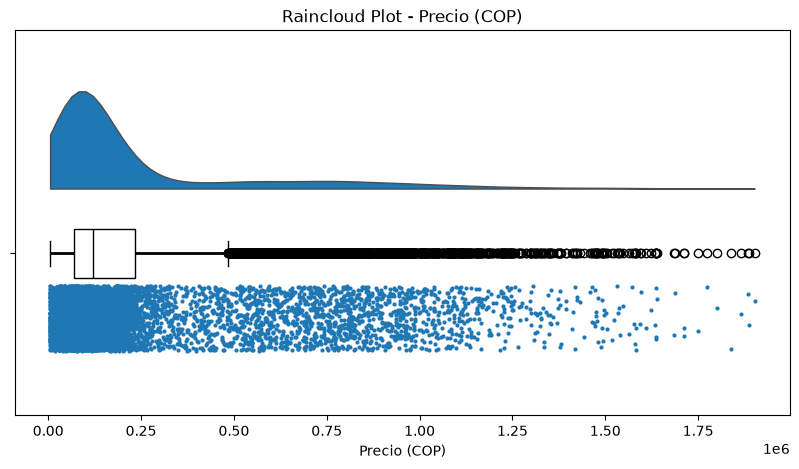

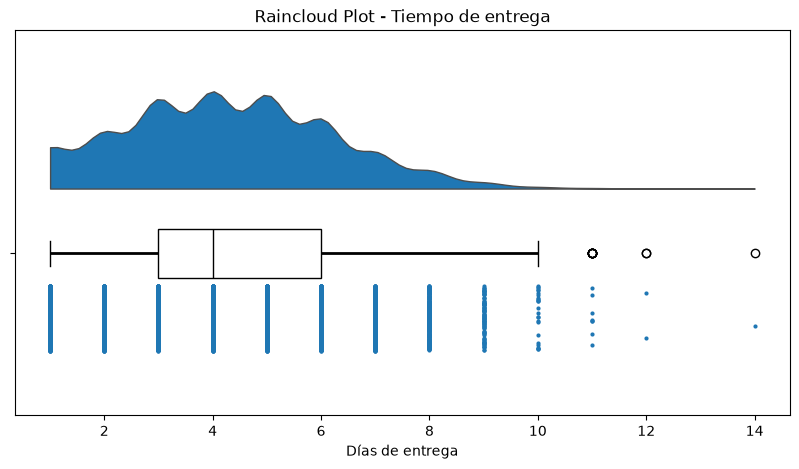

In [90]:
# -----------------------------
# Raincloud: Precio
# -----------------------------
plt.figure(figsize=(10, 5))

pt.RainCloud(
    y="precio_cop",
    data=df_limpio,
    orient="h",
    width_viol=.6,
    width_box=.15,
    point_size=3,
    move=0.2
)

plt.title("Raincloud Plot - Precio (COP)")
plt.xlabel("Precio (COP)")
plt.ylabel("")
plt.show()


# -----------------------------
# Raincloud: Tiempo de entrega
# -----------------------------
plt.figure(figsize=(10, 5))

pt.RainCloud(
    y="tiempo_entrega_dias",
    data=df_limpio,
    orient="h",
    width_viol=.6,
    width_box=.15,
    point_size=3,
    move=0.2
)

plt.title("Raincloud Plot - Tiempo de entrega")
plt.xlabel("Días de entrega")
plt.ylabel("")
plt.show()

- Precio

El raincloud plot de precio_cop muestra una distribución fuertemente asimétrica hacia la derecha en dónde la gran mayoría de las transacciones se concentra en precios bajos por debajo de $250.000 COP aproximadamente, mientras que una larga cola se extiende hasta cerca de $1.9 millones. El boxplot evidencia una enorme cantidad de puntos marcados como outliers (1.410 registros, 17.45% del total) por encima del límite superior de $483.968 COP calculado con el método IQR. Sin embargo, como se determinó previamente al segmentar por categoría de producto, esta "cola larga" no representa errores de datos, sino la superposición de varias distribuciones distintas dentro de una misma variable: los precios de categorías como Tecnología y Electrónica son naturalmente mucho más altos que los de Alimentos o Libros. Esto confirma que el método IQR aplicado sobre el precio global sobreestima la cantidad real de valores atípicos, y que un análisis correcto de outliers debe hacerse de forma independiente por categoría de producto. Esto se hará a continuación.

- Tiempo de entrega

El raincloud plot de tiempo_entrega_dias muestra una distribución mucho más simétrica y concentrada, con la mayoría de las entregas ocurriendo entre 1 y 10 días. El método IQR detectó solo 11 registros atípicos (0.14% del total), correspondientes a entregas de 11, 12 y 14 días, visibles como los puntos aislados a la derecha del boxplot. A diferencia del precio, en este caso los outliers sí representan una proporción mínima y no están asociados a una variable de segmentación evidente, por lo que corresponden más a variabilidad operativa normal del proceso logístico (por ejemplo, entregas en ciudades más alejadas o con incidencias puntuales) que a errores de captura.

- Atípicos precio de forma segmentada por categoría de producto

In [91]:

# Outliers de precio_cop segmentados por categoría de producto

df_limpio["categoria_norm"] = df_limpio["categoria_producto"].str.title()  # normalizar antes de agrupar
 
resultados_outliers = []
for categoria, grupo in df_limpio.groupby("categoria_norm"):
    q1 = grupo["precio_cop"].quantile(0.25)
    q3 = grupo["precio_cop"].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers_cat = grupo[(grupo["precio_cop"] < lim_inf) | (grupo["precio_cop"] > lim_sup)]
    resultados_outliers.append({
        "categoria": categoria,
        "n_registros": len(grupo),
        "q1": round(q1, 0),
        "q3": round(q3, 0),
        "limite_superior": round(lim_sup, 0),
        "n_outliers": len(outliers_cat),
        "pct_outliers": round(len(outliers_cat) / len(grupo) * 100, 2)
    })
 
outliers_por_categoria = pd.DataFrame(resultados_outliers).sort_values(
    "pct_outliers", ascending=False
)
 
print("\nOutliers de precio_cop segmentados por categoría:")
print(outliers_por_categoria.to_string(index=False))
print(f"\nTotal outliers segmentados por categoría: {outliers_por_categoria['n_outliers'].sum()}")
print(f"vs. total outliers con método global (sin segmentar): {len(outliers_precio)}")


Outliers de precio_cop segmentados por categoría:
  categoria  n_registros       q1        q3  limite_superior  n_outliers  pct_outliers
      Hogar          988 134086.0  224098.0         359118.0           9          0.91
 Tecnología          557 667058.0 1145083.0        1862120.0           4          0.72
Electrónica         1283 462880.0  820870.0        1357853.0           6          0.47
       Moda         1410  89288.0  155780.0         255517.0           5          0.35
    Belleza          902  59048.0  101662.0         165581.0           3          0.33
   Juguetes          563  67500.0  115864.0         188408.0           1          0.18
   Deportes          755 106286.0  188642.0         312176.0           1          0.13
  Alimentos          735  32356.0   57048.0          94085.0           0          0.00
     Libros          477  40432.0   69204.0         112362.0           0          0.00
   Mascotas          410  44608.0   90083.0         158296.0           0       

Debido a que el análisis global de outliers en precio_cop estaba influenciado por la heterogeneidad de precios entre categorías de producto, se recalculó el método IQR de forma independiente para cada una de las 10 categorías. Este enfoque segmentado redujo el número de valores atípicos de 1.410 a únicamente 29 registros, confirmando que la mayoría de los valores inicialmente marcados como atípicos correspondían a variabilidad normal de precio entre categorías y no a errores de datos. Las categorías con mayor proporción de outliers reales son Hogar con 0.91%, es decir 9 registros, Tecnología con 0.72%, es decir 4 registros y Electrónica con 0.47%, es decir 6 registros, mientras que Alimentos, Mascotas y Libros no presentan ningún valor atípico bajo este criterio segmentado. Este resultado confirma que el método de detección de outliers debe aplicarse por segmento cuando la variable analizada está naturalmente influenciada por otra variable categórica, como ocurre entre precio_cop y categoria_producto.

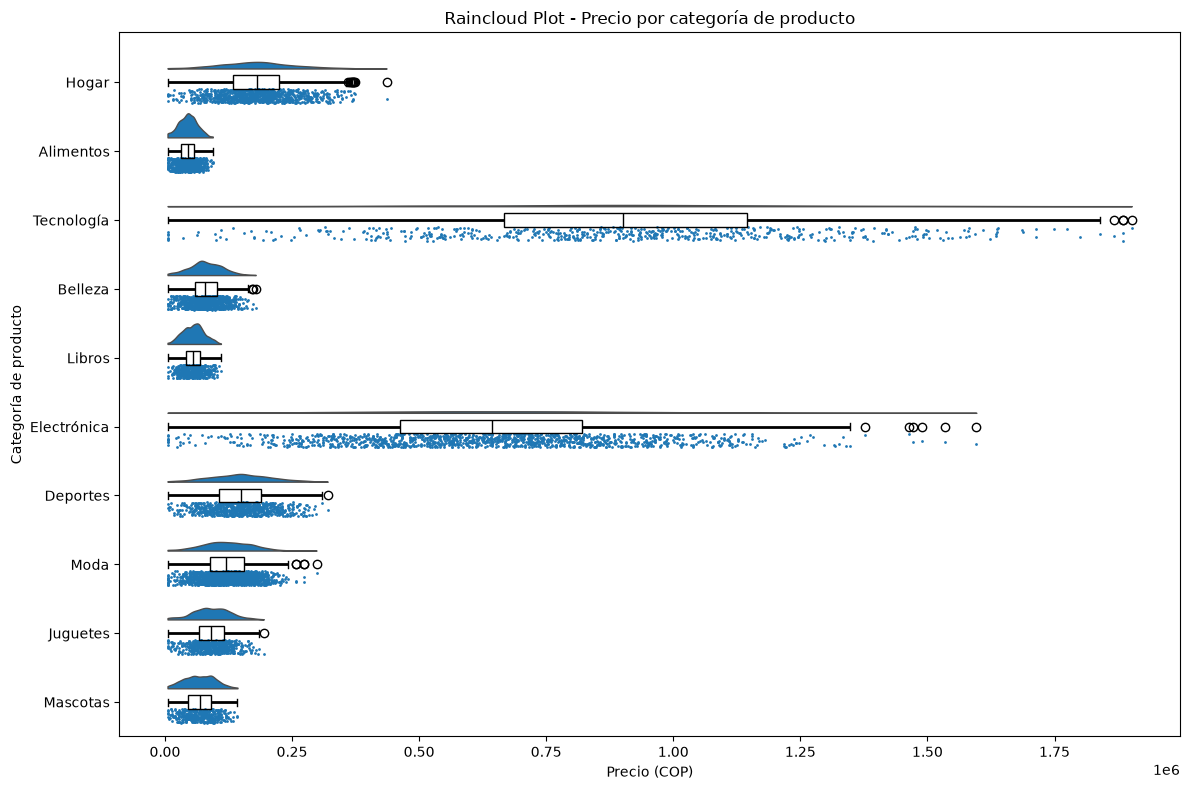

In [92]:
# Eliminar valores faltantes
df_raincloud = df_limpio[["categoria_norm", "precio_cop"]].dropna()

# Raincloud por categoría
plt.figure(figsize=(12, 8))

pt.RainCloud(
    x="categoria_norm",
    y="precio_cop",
    data=df_raincloud,
    orient="h",
    width_viol=0.7,
    width_box=0.2,
    point_size=2,
    move=0.2
)

plt.title("Raincloud Plot - Precio por categoría de producto")
plt.xlabel("Precio (COP)")
plt.ylabel("Categoría de producto")
plt.tight_layout()
plt.show()

El raincloud plot de precio segmentado por categoría de producto permite visualizar de forma directa por qué el análisis global de outliers era engañoso. Cada categoría presenta su propia distribución, mediana y rango: Tecnología y Electrónica no solo tienen los precios promedio más altos, sino también la mayor dispersión, mientras que categorías como Alimentos, Libros y Mascotas muestran distribuciones compactas y concentradas en valores bajos, con muy pocos o ningún punto marcado como atípico. Esto confirma visualmente que la variabilidad de precio observada en el análisis global no era ruido ni error, sino el resultado esperable de combinar diez categorías con estructuras de precio completamente distintas. Los pocos outliers detectados dentro de cada categoría sí representan casos puntuales que podrían revisarse de forma individual, en lugar de tratar indiscriminadamente el 17.45% de los datos como se sugería con el método sin segmentar.

# Preparación de los datos

## Tratamiento datos nulos

In [93]:
# Verificar si los nulos están relacionados con otras variables
# En este caso estaremos verificando elsupuesto de aleatoriedad / MCAR antes de decidir eliminar
print("\n--- Verificación de aleatoriedad de los nulos (MCAR) ---")
 
columnas_con_nulos = ["id_transaccion", "fecha_compra", "id_cliente", "dispositivo"]
 
for col in columnas_con_nulos:
    df_limpio["es_nulo"] = df_limpio[col].isnull()
 
    print(f"\n{col} nulo vs producto_devuelto (%):")
    print((pd.crosstab(df_limpio["es_nulo"], df_limpio["producto_devuelto"],
                        normalize="index") * 100).round(2))
 
    print(f"{col} nulo - calificación promedio:")
    print(df_limpio.groupby("es_nulo")["calificacion_cliente_1a5"].mean().round(3))
 
df_limpio.drop(columns=["es_nulo"], inplace=True)


--- Verificación de aleatoriedad de los nulos (MCAR) ---

id_transaccion nulo vs producto_devuelto (%):
producto_devuelto     No    Sí
es_nulo                       
False              96.48  3.52
True               96.73  3.27
id_transaccion nulo - calificación promedio:
es_nulo
False    4.946
True     4.971
Name: calificacion_cliente_1a5, dtype: float64

fecha_compra nulo vs producto_devuelto (%):
producto_devuelto     No    Sí
es_nulo                       
False              96.52  3.48
True               95.29  4.71
fecha_compra nulo - calificación promedio:
es_nulo
False    4.946
True     4.953
Name: calificacion_cliente_1a5, dtype: float64

id_cliente nulo vs producto_devuelto (%):
producto_devuelto     No    Sí
es_nulo                       
False              96.47  3.53
True               96.98  3.02
id_cliente nulo - calificación promedio:
es_nulo
False    4.948
True     4.898
Name: calificacion_cliente_1a5, dtype: float64

dispositivo nulo vs producto_devuelto (%):
product

Antes de definir el tratamiento de los valores faltantes, se verificó si su ausencia estaba relacionada con otras variables observadas. Para ello, se compararon producto_devuelto y calificacion_cliente_1a5 entre registros con y sin nulos en id_transaccion, fecha_compra, id_cliente y dispositivo.

Las diferencias fueron mínimas: la proporción de devoluciones varió entre 3.02% y 4.71%, frente a un promedio general de 3.53%, mientras que la calificación promedio se mantuvo entre 4.90 y 4.97. No se evidenciaron patrones sistemáticos asociados a los valores faltantes, por lo que se considera razonable asumir un comportamiento compatible con MCAR.

Además, dado que el porcentaje de nulos es bajo y corresponden principalmente a variables de identificación, se decidió eliminar estos registros en lugar de imputarlos.

In [94]:
# Eliminación (listwise) de registros sin id_transaccion, fecha_compra o id_cliente
# En este caso podemos decir que son llaves/referencias que no admiten imputación válida,
# y se verificó que su ausencia no está asociada a otras variables (MCAR).
antes = len(df_limpio)
df_limpio2 = df_limpio.dropna(subset=["id_transaccion", "fecha_compra", "id_cliente"]).copy()
despues = len(df_limpio2)
 
print(f"\nRegistros antes de eliminar nulos en llaves: {antes}")
print(f"Registros después de eliminar nulos en llaves: {despues}")
print(f"Registros eliminados: {antes - despues} "
      f"({round((antes - despues) / antes * 100, 2)}%)")


Registros antes de eliminar nulos en llaves: 8080
Registros después de eliminar nulos en llaves: 7339
Registros eliminados: 741 (9.17%)


Se eliminaron 741 registros es decir 9.17% al retirar los nulos en las tres llaves (id_transaccion, fecha_compra, id_cliente). Este porcentaje es mayor que el de cada variable individual todas por debajo del 3.3%, porque la eliminación se hace por unión: basta con que una sola de las tres columnas esté vacía para perder la fila completa. De hecho, 24 registros tenían nulos en dos de estas columnas al mismo tiempo, por lo que el total de filas afectadas (741) es menor que la suma de nulos por columna considerados por separado (765).

Aunque el 9.17% supera el umbral del 5% que suele usarse como referencia para la eliminación segura, se mantiene la decisión de eliminar estos registros porque: (1) corresponden a llaves/referencias que no admiten una imputación válida sin inventar información (un id de transacción o de cliente no se puede "estimar"), y (2) ya se verificó que su ausencia es MCAR, por lo que eliminar estas filas no introduce sesgo sistemático en el resto de las variables.

In [95]:
# Comparar la distribución de las variables antes vs. después de eliminar
# (verificación de que la eliminación no introduce sesgo / cambia la mediana)
print("\n--- Comparación de mediana y media (numéricas): antes vs. después ---")
numericas = ["precio_cop", "tiempo_entrega_dias", "calificacion_cliente_1a5"]
comparacion_numerica = pd.DataFrame({
    "mediana_antes": df_limpio[numericas].median(),
    "mediana_despues": df_limpio2[numericas].median(),
    "media_antes": df_limpio[numericas].mean().round(2),
    "media_despues": df_limpio2[numericas].mean().round(2),
})
print(comparacion_numerica)
 
print("\n--- Comparación de distribución (%) de variables categóricas: antes vs. después ---")
for col in ["categoria_producto", "metodo_pago", "canal"]:
    dist_antes = df_limpio[col].value_counts(normalize=True).round(3) * 100
    dist_despues = df_limpio2[col].value_counts(normalize=True).round(3) * 100
    comparacion_cat = pd.DataFrame({"antes_%": dist_antes, "despues_%": dist_despues})
    print(f"\n{col}:")
    print(comparacion_cat)


--- Comparación de mediana y media (numéricas): antes vs. después ---
                          mediana_antes  mediana_despues  media_antes  \
precio_cop                     120106.0         119717.0    248563.98   
tiempo_entrega_dias                 4.0              4.0         4.26   
calificacion_cliente_1a5            5.0              5.0         4.95   

                          media_despues  
precio_cop                    248125.27  
tiempo_entrega_dias                4.26  
calificacion_cliente_1a5           4.95  

--- Comparación de distribución (%) de variables categóricas: antes vs. después ---

categoria_producto:
                    antes_%  despues_%
categoria_producto                    
Moda                   17.5       17.4
Electrónica            15.9       15.8
Hogar                  12.2       12.1
Belleza                11.2       11.1
Deportes                9.3        9.3
Alimentos               9.1        9.1
Juguetes                7.0        7.0
Tecnología 

En este caso la comparación confirma que eliminar los 741 registros no distorsionó el resto del dataset. En las variables numéricas, las medianas se mantuvieron prácticamente iguales, cómo por ejemplo lo podemos ver en precio_cop dónde pasó de 120.106 a 119.717, una variación menor al 0.5% y las medias apenas se movieron precio_cop de 248.564 a 248.125; tiempo_entrega_dias y calificacion_cliente_1a5 sin cambio en el redondeo. En las variables categóricas cómo categoria_producto, metodo_pago, canal; las proporciones antes y después difieren como máximo en 0.1–0.2 puntos porcentuales, es decir, el orden y el peso relativo de cada categoría se conserva.

Esto es evidencia empírica adicional, más allá de la prueba de aleatoriedad MCAR ya realizada, de que la eliminación fue una decisión segura: no favoreció ningún segmento de precio, canal, categoría o método de pago en particular, por lo que el dataset resultante sigue siendo representativo del original pese al 9.17% de registros eliminados.

- Tratamiento de valores nulos en la variable dispositivo

A diferencia de variables cómo id_transaccion, fecha_compra e id_cliente, la variable dispositivo no es una llave ni una referencia: es un campo descriptivo de uso analítico. Esto significa que, además de la eliminación, tiene sentido explorar la imputación como alternativa válida, ya que conservar el registro completo con sus 11 columnas restantes intactas, es dónde aporta más valor que perder la fila solo por un dato faltante en un campo no crítico.

En la verificación de aleatoriedad (MCAR) realizada anteriormente ya se comparó dispositivo frente a producto_devuelto y calificacion_cliente_1a5, sin encontrar diferencias relevantes entre los registros con y sin nulo. Adicionalmente, se valida a continuación si dispositivo guarda relación con canal (App móvil / Sitio web), que sería la variable más lógica para explicar su ausencia.

In [96]:
# Verificar si la ausencia de dispositivo está asociada al canal de compra
print("Distribución de dispositivo según canal (entre no nulos):")
print((pd.crosstab(df_limpio2["canal"], df_limpio2["dispositivo"], normalize="index") * 100).round(2))

Distribución de dispositivo según canal (entre no nulos):
dispositivo  Android  Desktop    iOS
canal                               
App móvil      54.69    20.47  24.84
Sitio web      55.21    20.69  24.09


La distribución de dispositivo es prácticamente idéntica entre quienes compraron por App móvil cómo por ejemplo Android 54.69%, Desktop 20.47%, iOS 24.84% y por Sitio web cómo por ejemplo Android 55.21%, Desktop 20.69%, iOS 24.09%, con diferencias menores a un punto porcentual en cada categoría. Esto indica que el canal de compra no explica ni predice el valor de dispositivo, por lo que no existe una regla determinista (por ejemplo, "si es Sitio web, entonces es Desktop") que permita imputar los nulos con base en esta variable.

Este resultado refuerza la conclusión de que la ausencia de dispositivo es aleatoria (MCAR) y descarta una imputación basada en reglas o en un modelo predictivo usando canal como variable auxiliar. Por eso, a continuación se comparan métodos de imputación más simples cómo moda vs. proporcional, y no un enfoque predictivo que aquí no estaría justificado por los datos.

In [97]:
# Distribución original de dispositivo (sobre el dataset ya sin nulos en las llaves)
dist_original = df_limpio2["dispositivo"].value_counts(normalize=True).round(4) * 100
print("Distribución original de dispositivo (%):")
print(dist_original)
print(f"\nRegistros con dispositivo nulo: {df_limpio2['dispositivo'].isnull().sum()} "
      f"({df_limpio2['dispositivo'].isnull().mean()*100:.2f}%)")

Distribución original de dispositivo (%):
dispositivo
Android    54.89
iOS        24.56
Desktop    20.55
Name: proportion, dtype: float64

Registros con dispositivo nulo: 226 (3.08%)


Sobre el dataset ya depurado de nulos en las llaves (df_limpio2, 7.339 registros), dispositivo presenta 226 valores faltantes (3.08%), un porcentaje bajo y consistente con el reportado inicialmente sobre el dataset completo. La distribución observada entre los registros no nulos está concentrada en Android (54.89%), seguida de iOS (24.56%) y Desktop (20.55%).

Esta distribución es el punto de referencia ("original") contra el cual se comparará el efecto de cada método de tratamiento (eliminación, moda, proporcional) en la siguiente celda, el método elegido debe ser el que menos distorsione estas tres proporciones.

### Comparación de métodos: eliminación vs. imputación por moda vs. imputación proporcional

Se prueban tres tratamientos para los 226 nulos restantes en dispositivo y se compara, en cada caso, la distribución de categorías resultante contra la distribución original:

- **Eliminación (listwise):** descarta las filas con dispositivo nulo.
- **Imputación por moda:** reemplaza los nulos por la categoría más frecuente (Android).
- **Imputación proporcional (estocástica):** reemplaza cada nulo por un valor generado aleatoriamente respetando las proporciones observadas de Android/iOS/Desktop (consistente con el mecanismo MCAR ya verificado).

In [98]:
np.random.seed(42)  # reproducibilidad de la imputación estocástica

# --- Opción A: eliminación ---
df_disp_elim = df_limpio2.dropna(subset=["dispositivo"]).copy()
dist_elim = df_disp_elim["dispositivo"].value_counts(normalize=True).round(4) * 100

# --- Opción B: imputación por moda ---
moda_dispositivo = df_limpio2["dispositivo"].mode()[0]
df_disp_moda = df_limpio2.copy()
df_disp_moda["dispositivo"] = df_disp_moda["dispositivo"].fillna(moda_dispositivo)
dist_moda = df_disp_moda["dispositivo"].value_counts(normalize=True).round(4) * 100

# --- Opción C: imputación proporcional / estocástica ---
# Cada nulo se reemplaza por una categoría muestreada según las proporciones observadas,
# en lugar de asignar siempre la misma (la moda) a todos los registros faltantes.
probs = df_limpio2["dispositivo"].value_counts(normalize=True)
n_nulos = df_limpio2["dispositivo"].isnull().sum()
valores_imputados = np.random.choice(probs.index, size=n_nulos, p=probs.values)

df_disp_prop = df_limpio2.copy()
mask_nulos = df_disp_prop["dispositivo"].isnull()
df_disp_prop.loc[mask_nulos, "dispositivo"] = valores_imputados
dist_prop = df_disp_prop["dispositivo"].value_counts(normalize=True).round(4) * 100

# --- Tabla comparativa de distribuciones ---
comparacion_dispositivo = pd.DataFrame({
    "original_%": dist_original,
    "eliminacion_%": dist_elim,
    "moda_%": dist_moda,
    "proporcional_%": dist_prop,
})
comparacion_dispositivo["dif_moda_vs_original"] = (
    comparacion_dispositivo["moda_%"] - comparacion_dispositivo["original_%"]
).round(2)
comparacion_dispositivo["dif_proporcional_vs_original"] = (
    comparacion_dispositivo["proporcional_%"] - comparacion_dispositivo["original_%"]
).round(2)

print(comparacion_dispositivo)
print(f"\nRegistros conservados -> eliminación: {len(df_disp_elim)} | "
      f"moda / proporcional: {len(df_disp_moda)}")


             original_%  eliminacion_%  moda_%  proporcional_%  \
dispositivo                                                      
Android           54.89          54.89   56.27           54.97   
iOS               24.56          24.56   23.80           24.51   
Desktop           20.55          20.55   19.92           20.52   

             dif_moda_vs_original  dif_proporcional_vs_original  
dispositivo                                                      
Android                      1.38                          0.08  
iOS                         -0.76                         -0.05  
Desktop                     -0.63                         -0.03  

Registros conservados -> eliminación: 7113 | moda / proporcional: 7339


La tabla comparativa confirma numéricamente lo esperado: la eliminación, por construcción, reproduce exactamente la distribución original no puede alterarla, pero descarta 226 registros completos, quedando en 7.113 filas.

La imputación por moda es la que más distorsiona los datos, en dónde podemos ver que Android pasa de 54.89% a 56.27% (+1.38 puntos), a costa de reducir iOS (-0.76) y Desktop (-0.63). Esto ocurre porque el método asigna siempre la misma categoría la más frecuente a los 226 nulos, sin ninguna evidencia de que esos registros pertenezcan mayoritariamente a Android, dado que ya se comprobó que no hay relación con canal.

La imputación proporcional es la que mejor conserva la distribución original, las diferencias son mínimas en las tres categorías (+0.08, -0.05, -0.03 puntos), prácticamente indistinguibles del original, y conserva los 7.339 registros.

En conclusión dado que el objetivo es no distorsionar la variable, la imputación proporcional es la opción que mejor cumple ese criterio conservando además el tamaño muestral completo, mientras que la imputación por moda es la que se descarta por introducir un sesgo hacia Android que los datos no respaldan.

In [99]:
# Construcción del dataset final, llaves depuradas (df_limpio2) + dispositivo imputado
# de forma proporcional/estocástica según el método elegido y justificado arriba.
df_preparado = df_disp_prop.copy()

print("Nulos restantes por columna en el dataset preparado:")
print(df_preparado.isnull().sum())
print(f"\nRegistros finales: {len(df_preparado)} de {len(df)} originales "
      f"({len(df_preparado)/len(df)*100:.2f}%)")

Nulos restantes por columna en el dataset preparado:
id_transaccion              0
fecha_compra                0
id_cliente                  0
categoria_producto          0
precio_cop                  0
metodo_pago                 0
canal                       0
dispositivo                 0
ciudad_envio                0
tiempo_entrega_dias         0
calificacion_cliente_1a5    0
producto_devuelto           0
categoria_norm              0
dtype: int64

Registros finales: 7339 de 8080 originales (90.83%)


El dataset final df_preparado queda sin ningún valor nulo en sus 13 columnas. En total se conservan 7.339 de los 8.080 registros originales, es decir, se perdió únicamente el 9.17% correspondiente a los nulos no imputables en id_transaccion, fecha_compra e id_cliente (llaves/referencias). Los 226 nulos de dispositivo no restaron ningún registro adicional, ya que se resolvieron mediante imputación proporcional en lugar de eliminación.

Con esto queda cerrado el tratamiento de valores faltantes ya que cada una de las cuatro variables con nulos recibió un tratamiento distinto y justificado según su naturaleza (llave vs. descriptiva) y según cuál método distorsionaba menos la distribución original, evitando aplicar una misma regla genérica a todas.

## Tratamiento de duplicados
 
Como ahora df_limpio normaliza el texto de las columnas categoria_producto, ciudad_envio, tipo de id_cliente, desde el comienzo, el conteo de duplicados hecho en la sección de Trazabilidad ya es el correcto con 80 filas completamente duplicadas y 78 valores de id_transaccion repetidos, sin el riesgo de subestimarlos por diferencias de formato de texto. Por eso, en esta parte de Preparación de los datos no hace falta volver a normalizar nada; ya que solo queda **decidir el tratamiento** y aplicarlo sobre df_preparado (el dataset ya sin nulos en las llaves y con dispositivo imputado).
 

In [100]:
# Recalcular duplicados exactos sobre df_preparado
duplicados_preparado = df_preparado.duplicated().sum()
print(f"Duplicados exactos en df_preparado: {duplicados_preparado}")
 
conteo_ids = df_preparado["id_transaccion"].value_counts()
ids_repetidos = conteo_ids[conteo_ids > 1]
print(f"IDs de transacción repetidos en df_preparado: {len(ids_repetidos)}")
 
dup_exactos = df_preparado[df_preparado.duplicated(keep=False)]
ids_repetidos_no_exactos = set(ids_repetidos.index) - set(dup_exactos["id_transaccion"].unique())
print(f"IDs repetidos que NO son duplicado exacto (posible colisión real): "
      f"{len(ids_repetidos_no_exactos)}")

Duplicados exactos en df_preparado: 72
IDs de transacción repetidos en df_preparado: 72
IDs repetidos que NO son duplicado exacto (posible colisión real): 0


Sobre df_preparado ya sin nulos en las llaves y con dispositivo imputado quedan 72 duplicados exactos, exactamente igual al número de id_transaccion repetidos 72. Esto confirma que la relación es 1 a 1: cada id_transaccion que se repite lo hace porque toda la fila está duplicada, no porque dos transacciones distintas compartan accidentalmente el mismo identificador.
 
El hecho de que "IDs repetidos que NO son duplicado exacto" dé 0 es la verificación más importante, descarta que exista un problema real de integridad como por ejemplo una colisión de llave primaria, donde dos compras distintas tendrían el mismo id_transaccion. Al ser 0, queda claro que el único fenómeno presente es el de registros duplicados por error de sistema, lo cual justifica tratarlos simplemente con eliminación en el siguiente paso, sin necesidad de investigar más a fondo caso por caso.

- Decisión de tratamiento
 
Los 72 casos son duplicados **exactos**, idénticos en las 12 columnas, incluido id_transaccion. Se interpretan como errores de registro como por ejemplo, un doble clic al confirmar la compra o un reintento del sistema tras un fallo de red y no como transacciones legítimas distintas ya que dos transacciones reales no pueden coincidir en absolutamente todos los campos, incluyendo el identificador único.
 
Por eso se eliminan conservando la primera ocurrencia drop_duplicates(keep="first"). No se promedian ni se mantienen: mantenerlos infla artificialmente conteos y sumas sin aportar información nueva, ya que es la misma observación contada dos veces.

In [101]:
# Eliminar duplicados exactos, conservando la primera ocurrencia
antes = len(df_preparado)
df_final = df_preparado.drop_duplicates(keep="first").copy()
despues = len(df_final)
 
print(f"Registros antes de eliminar duplicados: {antes}")
print(f"Registros después de eliminar duplicados: {despues}")
print(f"Registros eliminados: {antes - despues} ({(antes - despues) / antes * 100:.2f}%)")

Registros antes de eliminar duplicados: 7339
Registros después de eliminar duplicados: 7267
Registros eliminados: 72 (0.98%)


Se eliminaron 72 registros duplicados es decir un porcentaje del0.98% del dataset, quedando 7.267 de los 7.339 registros que tenía df_preparado. A diferencia del 9.17% eliminado por nulos en las llaves, este porcentaje es muy bajo, lo cual es coherente con que se trata de un problema puntual errores de doble registro y no de un patrón extendido en los datos.
 
Con esta eliminación, cada fila de df_final representa ahora una transacción única, sin repeticiones que puedan inflar artificialmente conteos o promedios en los análisis posteriores.

In [102]:
# Comparar distribución antes vs. después de eliminar duplicados
numericas = ["precio_cop", "tiempo_entrega_dias", "calificacion_cliente_1a5"]
comparacion_dup = pd.DataFrame({
    "mediana_antes": df_preparado[numericas].median(),
    "mediana_despues": df_final[numericas].median(),
    "media_antes": df_preparado[numericas].mean().round(2),
    "media_despues": df_final[numericas].mean().round(2),
})
print(comparacion_dup)
 
print("\n--- Distribución (%) de categoria_producto: antes vs. después ---")
dist_antes = df_preparado["categoria_producto"].value_counts(normalize=True).round(3) * 100
dist_despues = df_final["categoria_producto"].value_counts(normalize=True).round(3) * 100
print(pd.DataFrame({"antes_%": dist_antes, "despues_%": dist_despues}))
 

                          mediana_antes  mediana_despues  media_antes  \
precio_cop                     119717.0         119824.0    248125.27   
tiempo_entrega_dias                 4.0              4.0         4.26   
calificacion_cliente_1a5            5.0              5.0         4.95   

                          media_despues  
precio_cop                    248357.23  
tiempo_entrega_dias                4.26  
calificacion_cliente_1a5           4.95  

--- Distribución (%) de categoria_producto: antes vs. después ---
                    antes_%  despues_%
categoria_producto                    
Alimentos               9.1        9.1
Belleza                11.1       11.1
Deportes                9.3        9.3
Electrónica            15.8       15.9
Hogar                  12.1       12.1
Juguetes                7.0        7.0
Libros                  5.8        5.9
Mascotas                5.2        5.2
Moda                   17.4       17.3
Tecnología              7.0        7.1


La comparación confirma que eliminar los 72 duplicados no distorsionó el dataset. En las variables numéricas, la mediana de precio_cop prácticamente no se movió de 119.717 a 119.824, una diferencia menor al 0.1%, y las medias tampoco cambiaron de forma perceptible; tiempo_entrega_dias y calificacion_cliente_1a5 se mantuvieron idénticas incluso en el redondeo. En categoria_producto, las proporciones antes y después difieren como máximo en 0.1 punto porcentual en dónde podemos encontrar que Moda pasa de 17.4% a 17.3%, Electrónica de 15.8% a 15.9%, lo que confirma que ninguna categoría estaba sobrerrepresentada por culpa de los duplicados.

## Tratamiento de valores atípicos

En la sección de Comprensión de los datos ya se estableció el criterio correcto para detectar atípicos en precio_cop, el método IQR *segmentado por categoría de producto*, ya que el método global sobreestimaba el problema con 1.410 falsos atípicos es decir 17.45% al mezclar categorías con estructuras de precio muy distintas. También se detectaron atípicos en tiempo_entrega_dias con IQR global en dónde se vieron 11 registros es decir un 0.14%.

Ahora, sobre df_final ya sin nulos en llaves ni duplicados, se recalculan estos atípicos y se decide qué tratamiento aplicarles ya sea mantenerlos, eliminarlos.

In [103]:
# Recalcular outliers de precio_cop (IQR segmentado por categoría) sobre df_final
limites_precio = {}
outliers_precio_idx = []
 
for categoria, grupo in df_final.groupby("categoria_producto"):
    q1 = grupo["precio_cop"].quantile(0.25)
    q3 = grupo["precio_cop"].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    limites_precio[categoria] = (lim_inf, lim_sup)
    out_cat = grupo[(grupo["precio_cop"] < lim_inf) | (grupo["precio_cop"] > lim_sup)]
    outliers_precio_idx.extend(out_cat.index.tolist())
 
print(f"Outliers de precio_cop (segmentados por categoría): {len(outliers_precio_idx)} "
      f"({len(outliers_precio_idx) / len(df_final) * 100:.2f}%)")
 
# Recalcular outliers de tiempo_entrega_dias (IQR global)
q1_t = df_final["tiempo_entrega_dias"].quantile(0.25)
q3_t = df_final["tiempo_entrega_dias"].quantile(0.75)
iqr_t = q3_t - q1_t
lim_inf_t = q1_t - 1.5 * iqr_t
lim_sup_t = q3_t + 1.5 * iqr_t
outliers_tiempo_idx = df_final[
    (df_final["tiempo_entrega_dias"] < lim_inf_t) | (df_final["tiempo_entrega_dias"] > lim_sup_t)
].index
 
print(f"Outliers de tiempo_entrega_dias: {len(outliers_tiempo_idx)} "
      f"({len(outliers_tiempo_idx) / len(df_final) * 100:.2f}%)")

Outliers de precio_cop (segmentados por categoría): 24 (0.33%)
Outliers de tiempo_entrega_dias: 10 (0.14%)


Sobre df_final de 7.267 registros, ya sin nulos ni duplicados, se confirma que los valores atípicos representan una proporción muy baja de los datos con un total de 24 registros en precio_cop es decir un 0.33%, usando el método IQR segmentado por categoría, y 10 registros en tiempo_entrega_dias es decir un 0.14% usando IQR global.
 
Estos números son consistentes con lo detectado inicialmente en la sección de Comprensión de los datos, con la diferencia de que ahora se calculan sobre el dataset ya depurado de nulos y duplicados, por lo que reflejan el porcentaje real de atípicos que queda para tratar en esta etapa. Al tratarse de porcentajes tan bajos, cualquier tratamiento que se elija (mantener, eliminar o capar) tendrá un efecto marginal sobre las estadísticas generales del dataset, como se verá en la comparación siguiente.

In [104]:
# Revisar los valores puntuales para descartar errores de captura (negativos, ceros, absurdos)
print("Valores atípicos de precio_cop por categoría:")
print(df_final.loc[outliers_precio_idx, ["categoria_producto", "precio_cop"]]
      .sort_values(["categoria_producto", "precio_cop"]).to_string(index=False))
 
print("\nValores atípicos de tiempo_entrega_dias:")
print(df_final.loc[outliers_tiempo_idx, "tiempo_entrega_dias"].value_counts().sort_index())

Valores atípicos de precio_cop por categoría:
categoria_producto  precio_cop
         Alimentos     93983.0
           Belleza    170977.0
           Belleza    173136.0
           Belleza    178490.0
          Deportes    320088.0
       Electrónica   1346866.0
       Electrónica   1378107.0
       Electrónica   1464294.0
       Electrónica   1471001.0
       Electrónica   1596268.0
             Hogar    366240.0
             Hogar    368115.0
             Hogar    369916.0
             Hogar    370300.0
             Hogar    372594.0
             Hogar    374410.0
             Hogar    435935.0
          Juguetes    194332.0
              Moda    256819.0
              Moda    257827.0
              Moda    272775.0
              Moda    273082.0
              Moda    298134.0
        Tecnología   1902012.0

Valores atípicos de tiempo_entrega_dias:
tiempo_entrega_dias
11.0    7
12.0    2
14.0    1
Name: count, dtype: int64


Al inspeccionar los valores puntuales, se confirma que ninguno corresponde a un error evidente de captura ya que no hay precios negativos, en cero, ni desproporcionados frente a lo que ya se conocía del dataset. Hogar concentra la mayor cantidad de atípicos con 7 registros, entre $366.240 y $435.935, seguida de Electrónica con 5 registros, hasta $1.596.268 y Moda con 5 registros. El valor más alto de todos, $1.902.012 en Tecnología, coincide exactamente con el precio máximo ya reportado desde el describe() inicial del dataset, es decir, no es un dato nuevo o sospechoso, es el producto más caro que ya se sabía que existía en la base.
 
En tiempo_entrega_dias, los 10 atípicos se concentran en 11 días (7 casos), 12 días (2 casos) y 14 días (1 caso): un patrón concentrado y gradual, no valores sueltos o imposibles como 100 días, lo que refuerza que se trata de entregas real pero inusualmente demoradas, y no de errores de digitación.

Se decide mantener los valores atípicos sin modificarlos, tanto en precio_cop como en tiempo_entrega_dias. Los precios identificados como atípicos (hasta $1.902.012 en Tecnología, hasta $435.935 en Hogar) son coherentes con precios de mercado reales para esas categorías de producto, no valores fuera de lo común ni desproporcionados; de hecho, el máximo coincide con el precio máximo ya reportado desde el resumen inicial del dataset. De igual forma, las entregas de 11 a 14 días están dentro de un rango operativo razonable para un e-commerce, no representan demoras imposibles.
 
Al no haber evidencia de que estos valores sean errores de captura o mediciones inválidas, no se justifica eliminarlos ni modificarlos artificialmente, hacerlo descartaría información real sobre productos premium y entregas más demoradas, sin ninguna ganancia a cambio.

## Normalización de variables categóricas

In [105]:
# Revisar valores únicos de cada variable categórica
columnas_categoricas = [
    "categoria_producto", "metodo_pago", "canal",
    "dispositivo", "ciudad_envio", "producto_devuelto"
]
 
for col in columnas_categoricas:
    valores = sorted(df_final[col].dropna().unique())
    print(f"\n--- {col} ({len(valores)} valores únicos) ---")
    print(valores)
 


--- categoria_producto (10 valores únicos) ---
['Alimentos', 'Belleza', 'Deportes', 'Electrónica', 'Hogar', 'Juguetes', 'Libros', 'Mascotas', 'Moda', 'Tecnología']

--- metodo_pago (5 valores únicos) ---
['Billetera digital', 'Contraentrega', 'PSE', 'Tarjeta crédito', 'Tarjeta débito']

--- canal (2 valores únicos) ---
['App móvil', 'Sitio web']

--- dispositivo (3 valores únicos) ---
['Android', 'Desktop', 'iOS']

--- ciudad_envio (10 valores únicos) ---
['Barranquilla', 'Bogotá', 'Bucaramanga', 'Cali', 'Cartagena', 'Cúcuta', 'Ibagué', 'Manizales', 'Medellín', 'Pereira']

--- producto_devuelto (2 valores únicos) ---
['No', 'Sí']


Como esto ya se hizo anteriormente en la calidad de los datos, esto es más que todo para que se evidencie que se mantiene esa normalización a lo largo de todo el trabajo.

# Sesgos

In [ ]:

# Auditoría de sesgo: representatividad antes vs después


variables = [
    "categoria_producto",
    "ciudad_envio",
    "metodo_pago",
    "canal",
    "dispositivo",
    "producto_devuelto"
]

for col in variables:

    print(f"\n{'='*60}")
    print(col.upper())
    print("="*60)

    antes = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .rename("antes")
        *100
    )

    despues = (
        df_final[col]
        .value_counts(normalize=True, dropna=False)
        .rename("despues")
        *100
    )

    comparacion = pd.concat([antes, despues], axis=1)

    comparacion["diferencia"] = (
        comparacion["despues"]-comparacion["antes"]
    ).round(2)

    print(comparacion.fillna(0).round(2))


CATEGORIA_PRODUCTO
                    antes  despues  diferencia
categoria_producto                            
Moda                16.46    17.32        0.86
Electrónica         14.94    15.87        0.93
Hogar               11.52    12.11        0.59
Belleza             10.54    11.10        0.56
Deportes             8.73     9.33        0.60
Alimentos            8.70     9.08        0.38
Tecnología           6.63     7.07        0.44
Juguetes             6.60     7.03        0.44
Libros               5.68     5.86        0.18
Mascotas             4.83     5.22        0.39
MODA                 0.99     0.00        0.00
ELECTRÓNICA          0.94     0.00        0.00
HOGAR                0.71     0.00        0.00
DEPORTES             0.62     0.00        0.00
BELLEZA              0.62     0.00        0.00
ALIMENTOS            0.40     0.00        0.00
JUGUETES             0.37     0.00        0.00
TECNOLOGÍA           0.26     0.00        0.00
MASCOTAS             0.25     0.00      

In [107]:
from scipy.stats import chi2_contingency

variables = [
    "categoria_producto",
    "ciudad_envio",
    "metodo_pago",
    "canal",
    "dispositivo",
    "producto_devuelto"
]

for col in variables:

    df["origen"] = "Original"
    df_final["origen"] = "Final"

    temp = pd.concat([
        df[[col,"origen"]],
        df_final[[col,"origen"]]
    ])

    tabla = pd.crosstab(temp[col], temp["origen"])

    chi2,p,_,_ = chi2_contingency(tabla)

    print(f"{col:25}  p-value = {p:.4f}")

categoria_producto         p-value = 0.0000
ciudad_envio               p-value = 0.0000
metodo_pago                p-value = 0.9996
canal                      p-value = 0.8629
dispositivo                p-value = 0.9209
producto_devuelto          p-value = 1.0000


La comparación entre la distribución original y la distribución final muestra un cambio estadísticamente significativo (p < 0.001). Sin embargo, este resultado no corresponde a una pérdida de representatividad, sino al proceso de normalización de variables categóricas realizado durante la limpieza.

En el dataset original existían categorías duplicadas por diferencias de formato, por ejemplo "Moda" y "MODA", "Electrónica" y "ELECTRÓNICA", entre otras. Al unificarlas bajo una única categoría, sus frecuencias se sumaron, generando incrementos inferiores a un punto porcentual (por ejemplo, Moda pasó de 16.46% a 17.32% y Electrónica de 14.94% a 15.87%).

Por tanto, el cambio detectado por la prueba estadística refleja una corrección de calidad de datos y no un sesgo introducido en la representación de las categorías.

In [ ]:

# Auditoría de sesgo - Ciudad de envío


antes = (
    df["ciudad_envio"]
    .value_counts(normalize=True, dropna=False)
    .rename("antes")
    * 100
)

despues = (
    df_final["ciudad_envio"]
    .value_counts(normalize=True, dropna=False)
    .rename("despues")
    * 100
)

comparacion = pd.concat([antes, despues], axis=1)

comparacion["diferencia"] = (
    comparacion["despues"] - comparacion["antes"]
).round(2)

comparacion = comparacion.fillna(0).round(2)

print(comparacion)

print("\nMayor diferencia encontrada:")
print(comparacion["diferencia"].abs().max())

              antes  despues  diferencia
ciudad_envio                            
Bogotá        27.97    29.45        1.48
Medellín      14.88    15.82        0.95
Cali          12.83    13.31        0.47
Barranquilla   8.71     9.16        0.45
Bucaramanga    6.60     6.88        0.28
Cartagena      5.72     5.99        0.27
Pereira        5.66     6.05        0.40
Manizales      4.53     5.00        0.47
Ibagué         4.07     4.39        0.32
Cúcuta         3.91     3.95        0.04
BOGOTÁ         1.27     0.00        0.00
MEDELLÍN       0.83     0.00        0.00
CALI           0.59     0.00        0.00
BARRANQUILLA   0.51     0.00        0.00
PEREIRA        0.38     0.00        0.00
BUCARAMANGA    0.38     0.00        0.00
CARTAGENA      0.32     0.00        0.00
IBAGUÉ         0.30     0.00        0.00
MANIZALES      0.27     0.00        0.00
CÚCUTA         0.26     0.00        0.00

Mayor diferencia encontrada:
1.48


In [110]:
from scipy.stats import chi2_contingency
import pandas as pd

# Copias con índices reiniciados
antes = df.copy().reset_index(drop=True)
despues = df_final.copy().reset_index(drop=True)

antes["origen"] = "Antes"
despues["origen"] = "Después"

datos = pd.concat([antes, despues], ignore_index=True)

tabla = pd.crosstab(
    datos["ciudad_envio"],
    datos["origen"]
)

chi2, p, gl, esperados = chi2_contingency(tabla)

print(f"Chi² = {chi2:.4f}")
print(f"p-value = {p:.8f}")

Chi² = 383.6804
p-value = 0.00000000


In [111]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Copias con índices reiniciados
antes = df.copy().reset_index(drop=True)
despues = df_final.copy().reset_index(drop=True)

antes["origen"] = "Antes"
despues["origen"] = "Después"

datos = pd.concat([antes, despues], ignore_index=True)

# Tabla de contingencia
tabla = pd.crosstab(datos["ciudad_envio"], datos["origen"])

# Chi-cuadrado
chi2, p, _, _ = chi2_contingency(tabla)

# Cramér's V
n = tabla.to_numpy().sum()
k = min(tabla.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))

print(f"Chi²      : {chi2:.4f}")
print(f"p-value   : {p:.8f}")
print(f"Cramér's V: {cramers_v:.4f}")

# Interpretación
if cramers_v < 0.10:
    print("Interpretación: efecto despreciable.")
elif cramers_v < 0.30:
    print("Interpretación: efecto pequeño.")
elif cramers_v < 0.50:
    print("Interpretación: efecto moderado.")
else:
    print("Interpretación: efecto fuerte.")

Chi²      : 383.6804
p-value   : 0.00000000
Cramér's V: 0.1581
Interpretación: efecto pequeño.


La comparación de la variable ciudad_envio mostró diferencias estadísticamente significativas entre el conjunto original y el conjunto limpio (χ² = 383.68, p < 0.001). El tamaño del efecto fue pequeño (Cramér's V = 0.1581), indicando una modificación limitada en la distribución. Al revisar las frecuencias se evidenció que el cambio se originó por la unificación de ciudades registradas con diferentes formatos de escritura (por ejemplo, "Bogotá" y "BOGOTÁ"), sin eliminar categorías ni alterar la representatividad geográfica del conjunto de datos. En consecuencia, el cambio corresponde a una mejora en la calidad del dato y no a un sesgo introducido por el proceso de limpieza.

In [ ]:

# Auditoría de sesgo - Método de pago


antes = (
    df["metodo_pago"]
    .value_counts(normalize=True)
    .rename("antes") * 100
)

despues = (
    df_final["metodo_pago"]
    .value_counts(normalize=True)
    .rename("despues") * 100
)

comparacion = pd.concat([antes, despues], axis=1)

comparacion["diferencia"] = (
    comparacion["despues"] - comparacion["antes"]
).round(2)

comparacion = comparacion.fillna(0).round(2)

print(comparacion)

print("\nMayor diferencia:")
print(comparacion["diferencia"].abs().max())

                   antes  despues  diferencia
metodo_pago                                  
Tarjeta crédito    35.14    35.06       -0.07
Tarjeta débito     19.88    19.91        0.04
PSE                19.88    19.84       -0.03
Contraentrega      14.95    14.92       -0.03
Billetera digital  10.16    10.27        0.10

Mayor diferencia:
0.1


Este resultado indica que la distribución del método de pago permaneció prácticamente idéntica antes y después del proceso de limpieza. Las diferencias observadas son inferiores a 0.1 puntos porcentuales, por lo que no existe evidencia de una alteración en la representatividad de esta variable.

In [ ]:

# Auditoría de sesgo - Canal


antes = (
    df["canal"]
    .value_counts(normalize=True)
    .rename("antes") * 100
)

despues = (
    df_final["canal"]
    .value_counts(normalize=True)
    .rename("despues") * 100
)

comparacion = pd.concat([antes, despues], axis=1)

comparacion["diferencia"] = (
    comparacion["despues"] - comparacion["antes"]
).round(2)

comparacion = comparacion.fillna(0).round(2)

print(comparacion)

print("\nMayor diferencia:")
print(comparacion["diferencia"].abs().max())

           antes  despues  diferencia
canal                                
App móvil  62.51    62.36       -0.15
Sitio web  37.49    37.64        0.15

Mayor diferencia:
0.15


La distribución del canal de compra permaneció prácticamente inalterada tras el proceso de limpieza. La diferencia máxima observada fue de apenas 0.15 puntos porcentuales, lo que indica que las decisiones de preparación de datos no modificaron la proporción de compras realizadas desde la aplicación móvil y el sitio web.

In [ ]:

# Auditoría de sesgo - Dispositivo


antes = (
    df["dispositivo"]
    .value_counts(normalize=True, dropna=False)
    .rename("antes") * 100
)

despues = (
    df_final["dispositivo"]
    .value_counts(normalize=True, dropna=False)
    .rename("despues") * 100
)

comparacion = pd.concat([antes, despues], axis=1)

comparacion["diferencia"] = (
    comparacion["despues"] - comparacion["antes"]
).round(2)

comparacion = comparacion.fillna(0).round(2)

print(comparacion)

print("\nMayor diferencia:")
print(comparacion["diferencia"].abs().max())

             antes  despues  diferencia
dispositivo                            
Android      53.24    54.97        1.73
iOS          23.87    24.43        0.55
Desktop      19.74    20.60        0.86
NaN           3.14     0.00        0.00

Mayor diferencia:
1.73


In [ ]:

# Auditoría de la imputación de 'dispositivo'
# Comparación excluyendo valores nulos


antes = (
    df["dispositivo"]
    .dropna()
    .value_counts(normalize=True)
    .rename("antes")
    * 100
)

despues = (
    df_final["dispositivo"]
    .value_counts(normalize=True)
    .rename("despues")
    * 100
)

comparacion = pd.concat([antes, despues], axis=1)

comparacion["diferencia"] = (
    comparacion["despues"] - comparacion["antes"]
).round(2)

print(comparacion.round(2))

print("\nMayor diferencia:")
print(comparacion["diferencia"].abs().max())

             antes  despues  diferencia
dispositivo                            
Android      54.97    54.97        0.00
iOS          24.65    24.43       -0.22
Desktop      20.38    20.60        0.22

Mayor diferencia:
0.22


Este resultado demuestra que la imputación proporcional preservó la distribución original de la variable dispositivo.

Las diferencias observadas son inferiores a 0.25 puntos porcentuales, por lo que el método de imputación no favoreció ninguna categoría ni alteró la representatividad del conjunto de datos.

| Variable             | Conclusión                                          |
| -------------------- | --------------------------------------------------- |
| `categoria_producto` | ✅ Sin sesgo (normalización).                        |
| `ciudad_envio`       | ✅ Sin sesgo (normalización).                        |
| `metodo_pago`        | ✅ Sin sesgo.                                        |
| `canal`              | ✅ Sin sesgo.                                        |
| `dispositivo`        | ✅ Imputación proporcional preservó la distribución. |
| `producto_devuelto`  | ✅ Sin sesgo.                                        |
